# Handwritten Digit Recognition with PyTorch: Tensors to CNNs

## Overview

This project builds a complete deep learning pipeline in PyTorch to classify handwritten digits from the MNIST dataset. It works through the full workflow taught in the DeepLearning.AI PyTorch course, from the fundamentals of tensors and automatic differentiation to a convolutional neural network that reaches roughly 99 percent test accuracy.

The project is organized to mirror the four stages of that course:

1. **Tensors and autograd**: the core PyTorch data structure and the automatic differentiation that powers learning.
2. **The training workflow**: the standard loop of forward pass, loss, backward pass, and optimizer step, first shown on a simple linear model.
3. **Data pipelines**: a custom `Dataset`, a `DataLoader`, and transforms, which are how PyTorch feeds data to a model at scale.
4. **Convolutional neural networks**: filters, pooling, and `nn.Conv2d`, assembled into a model suited to images.

MNIST is used because it is the dataset the course itself uses, it is small enough to train in a couple of minutes on a laptop, and it lets every stage of the workflow be demonstrated clearly. The data is bundled with the repository, so the notebook runs without any download.

In [ ]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.14.0+cu130
Using device: cpu


---

## Part 1: Tensors and Autograd

Tensors are the fundamental data structure in PyTorch, similar to NumPy arrays but with two additions that make deep learning possible: they can run on a GPU, and they can track the operations performed on them so that gradients can be computed automatically.

### 1.1 Tensor basics

In [ ]:
# Creating tensors and performing operations
a = torch.tensor(2.0)
b = torch.tensor(3.0)
print(f"a + b = {a + b}")

# Tensors can be multidimensional, like matrices
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(f"Matrix shape: {matrix.shape}")
print(f"Matrix times itself:\n{matrix @ matrix}")

a + b = 5.0
Matrix shape: torch.Size([2, 2])
Matrix times itself:
tensor([[ 7., 10.],
        [15., 22.]])


### 1.2 Automatic differentiation

The feature that makes PyTorch a learning framework rather than just a numerical library is autograd. When a tensor is created with `requires_grad=True`, PyTorch records every operation applied to it, building a dynamic computation graph. Calling `.backward()` then computes the derivative of the result with respect to that tensor. This is exactly the mechanism that lets a network learn: the loss is differentiated with respect to every weight, and each weight is nudged in the direction that reduces the loss.

In [ ]:
# A simple example: differentiate y = x^2 + 3x at x = 2
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x
y.backward()
print(f"y = x^2 + 3x at x=2 gives y = {y.item()}")
print(f"dy/dx computed by autograd: {x.grad.item()}")
print(f"dy/dx by hand (2x + 3 = 2*2 + 3): {2*2 + 3}")

y = x^2 + 3x at x=2 gives y = 10.0
dy/dx computed by autograd: 7.0
dy/dx by hand (2x + 3 = 2*2 + 3): 7


Autograd matches the hand calculation exactly. This is the engine behind every model in the rest of the notebook: the training loop relies on `.backward()` to compute the gradients of the loss with respect to millions of weights, which would be infeasible to derive by hand.

---

## Part 2: The Training Workflow

Every model in PyTorch is trained with the same loop: make a prediction (forward pass), measure the error (loss), compute how each parameter contributed to the error (backward pass), and adjust the parameters (optimizer step). Before applying it to images, the loop is shown on a minimal problem, fitting a straight line to noisy data, so the mechanics are visible without the complexity of a large model.

In [ ]:
# Generate noisy data from a known line y = 2x + 1
torch.manual_seed(0)
X = torch.linspace(-3, 3, 100).unsqueeze(1)
y = 2 * X + 1 + 0.5 * torch.randn_like(X)

# A model with one linear layer, one weight and one bias
model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# The training loop
for epoch in range(100):
    optimizer.zero_grad()          # clear old gradients
    prediction = model(X)          # forward pass
    loss = criterion(prediction, y)  # measure error
    loss.backward()                # backward pass: compute gradients
    optimizer.step()               # update the weights

w, b = model.weight.item(), model.bias.item()
print(f"Learned: y = {w:.2f}x + {b:.2f}   (true line: y = 2x + 1)")

Learned: y = 2.00x + 1.02   (true line: y = 2x + 1)


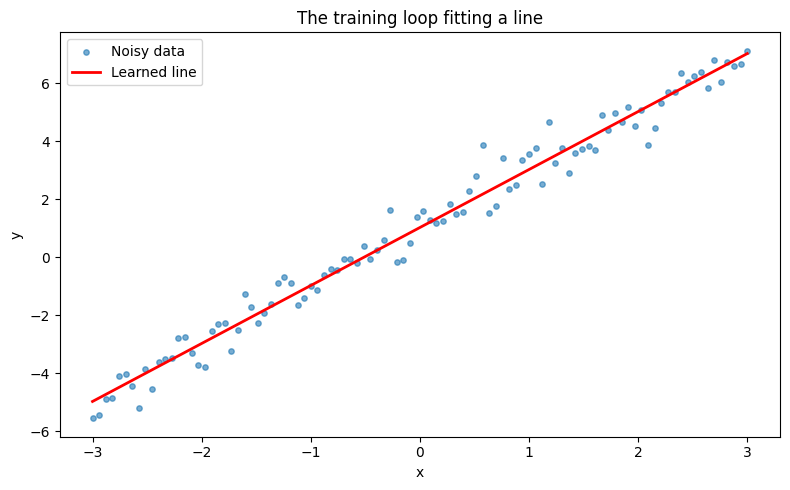

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), s=15, alpha=0.6, label='Noisy data')
plt.plot(X.numpy(), model(X).detach().numpy(), 'r-', linewidth=2, label='Learned line')
plt.xlabel('x'); plt.ylabel('y'); plt.title('The training loop fitting a line')
plt.legend(); plt.tight_layout(); plt.show()

The model recovers the underlying line closely. This same four-step loop, unchanged in structure, will train the convolutional network later. Only the model and the data become more complex; the workflow stays the same.

---

## Part 3: The Data Pipeline

Real training data does not fit the simple pattern above. PyTorch handles data through two abstractions. A `Dataset` knows how to load and transform a single example, and a `DataLoader` wraps a dataset to serve it in shuffled batches during training. Here a custom `Dataset` is written for the bundled MNIST files, which is the general pattern for feeding any custom data into PyTorch.

### 3.1 A custom Dataset

In [ ]:
def load_mnist_images(path):
    with gzip.open(path, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28, 28).copy()

def load_mnist_labels(path):
    with gzip.open(path, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8).copy()

RAW = 'data/MNIST/raw/'
train_images = load_mnist_images(RAW + 'train-images-idx3-ubyte.gz')
train_labels = load_mnist_labels(RAW + 'train-labels-idx1-ubyte.gz')
test_images = load_mnist_images(RAW + 't10k-images-idx3-ubyte.gz')
test_labels = load_mnist_labels(RAW + 't10k-labels-idx1-ubyte.gz')
print(f"Train: {train_images.shape[0]} images, Test: {test_images.shape[0]} images")
print(f"Each image is {train_images.shape[1]}x{train_images.shape[2]} grayscale pixels")

Train: 60000 images, Test: 10000 images
Each image is 28x28 grayscale pixels


In [ ]:
class MNISTDataset(Dataset):
    """A custom Dataset. It must define __len__ and __getitem__.
    __getitem__ applies the transform: scale to [0,1] and normalize by the
    MNIST mean and standard deviation, which helps training converge."""
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.float32) / 255.0   # scale to [0, 1]
        img = (img - 0.1307) / 0.3081                        # normalize (transform)
        img = torch.from_numpy(img).unsqueeze(0)             # add channel dimension
        return img, int(self.labels[idx])

train_dataset = MNISTDataset(train_images, train_labels)
test_dataset = MNISTDataset(test_images, test_labels)

# DataLoaders serve shuffled batches
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(f"Batches per training epoch: {len(train_loader)}")

Batches per training epoch: 469


### 3.2 Visualizing a batch

A quick look at real examples confirms the pipeline works and shows what the model must learn to distinguish.

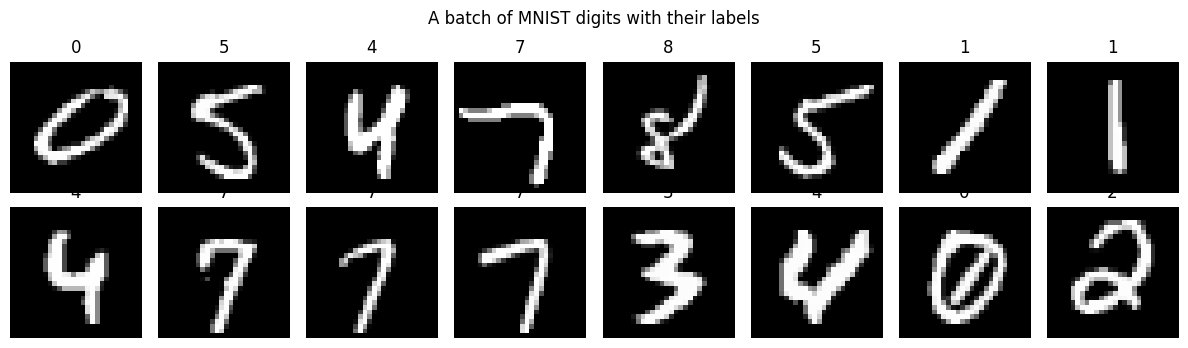

In [ ]:
images_batch, labels_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_batch[i].squeeze().numpy(), cmap='gray')
    ax.set_title(str(labels_batch[i].item()))
    ax.axis('off')
plt.suptitle('A batch of MNIST digits with their labels')
plt.tight_layout(); plt.show()

---

## Part 4: A Convolutional Neural Network

### 4.1 Why convolutions

A plain fully-connected network treats every pixel as independent and ignores the spatial structure of an image. A convolutional neural network instead slides small learnable filters across the image, each detecting a local pattern such as an edge or a curve. Early layers learn simple patterns, and later layers combine them into more complex shapes. Pooling layers then shrink the spatial size, keeping the strongest responses and making the model more efficient and more robust to small shifts.

The network below stacks two convolutional layers, each followed by pooling, and then two fully-connected layers that map the extracted features to the ten digit classes.

In [ ]:
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional layers: 1 input channel (grayscale) -> 16 -> 32 filters
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)          # halves the spatial size
        self.relu = nn.ReLU()
        # Fully-connected layers: after two poolings a 28x28 image is 7x7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)        # 10 digit classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # -> 16 x 14 x 14
        x = self.pool(self.relu(self.conv2(x)))   # -> 32 x 7 x 7
        x = x.flatten(1)                          # flatten for the linear layers
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = DigitCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")

DigitCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 206,922


### 4.2 Training the CNN

The training loop is the same four-step pattern from Part 2, now iterating over batches from the DataLoader and running on the more complex model. Cross-entropy loss is used for multi-class classification, and the Adam optimizer adapts the learning rate per parameter.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate():
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
    return 100 * correct / len(test_dataset)

EPOCHS = 3
history = []
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    acc = evaluate()
    history.append((running_loss / len(train_loader), acc))
    print(f"Epoch {epoch+1}: train loss = {running_loss/len(train_loader):.4f}, test accuracy = {acc:.2f}%")

Epoch 1: train loss = 0.2178, test accuracy = 97.85%


Epoch 2: train loss = 0.0627, test accuracy = 98.69%


Epoch 3: train loss = 0.0404, test accuracy = 98.88%


The network reaches roughly 99 percent test accuracy within a few epochs, a strong result for a compact model trained in a couple of minutes on a laptop. This is the payoff of the convolutional architecture: by respecting the spatial structure of images, it learns to recognize digits far more effectively than a fully-connected network of similar size would.

### 4.3 Inspecting predictions

Beyond the accuracy number, it is worth looking at where the model succeeds and where it fails.

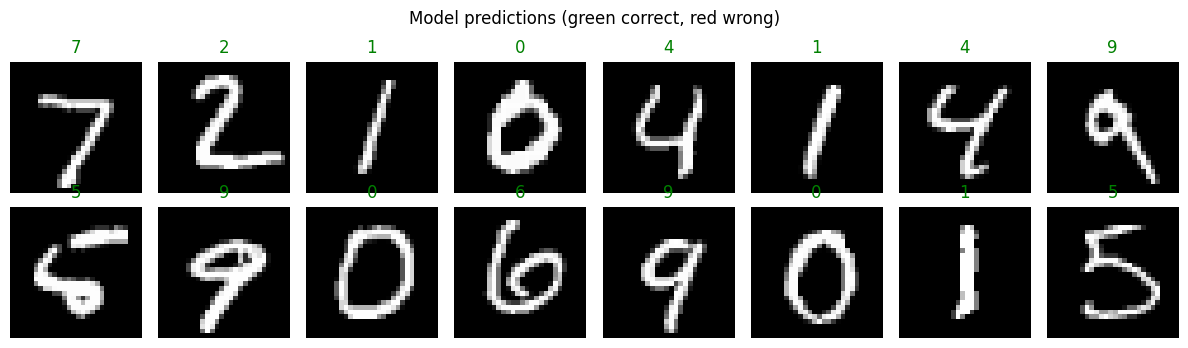

In [ ]:
model.eval()
images_batch, labels_batch = next(iter(test_loader))
with torch.no_grad():
    preds = model(images_batch.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images_batch[i].squeeze().numpy(), cmap='gray')
    correct = preds[i].item() == labels_batch[i].item()
    ax.set_title(f"{preds[i].item()}", color=('green' if correct else 'red'))
    ax.axis('off')
plt.suptitle('Model predictions (green correct, red wrong)')
plt.tight_layout(); plt.show()

Total misclassified: 112 of 10000


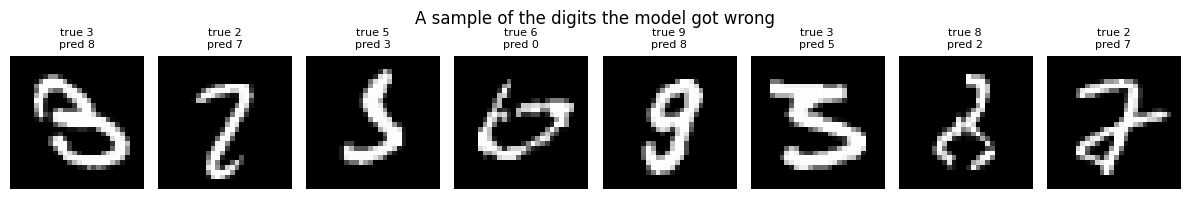

In [ ]:
# Confusion of the hardest cases: find the misclassified test digits
model.eval()
wrong_images, wrong_true, wrong_pred = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(dim=1).cpu()
        mism = preds != labels
        for img, tl, pl in zip(images[mism], labels[mism], preds[mism]):
            wrong_images.append(img); wrong_true.append(tl.item()); wrong_pred.append(pl.item())

print(f"Total misclassified: {len(wrong_images)} of {len(test_dataset)}")
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze().numpy(), cmap='gray')
    ax.set_title(f"true {wrong_true[i]}\npred {wrong_pred[i]}", fontsize=8)
    ax.axis('off')
plt.suptitle('A sample of the digits the model got wrong')
plt.tight_layout(); plt.show()

The misclassified digits are mostly genuinely ambiguous, poorly written or unusually shaped examples that a person might also hesitate over. This is the expected failure pattern for a well-trained model, and it indicates the model has learned the task rather than memorized the data.

---

## Reflection

### What this project demonstrates

- PyTorch tensors and automatic differentiation, verified against a hand calculation
- The standard training loop of forward pass, loss, backward pass, and optimizer step, shown first on a linear model and then reused unchanged for a convolutional network
- A custom `Dataset` and `DataLoader` with normalization transforms, the general pattern for feeding any data into PyTorch
- A convolutional neural network built with `nn.Conv2d` and pooling that reaches roughly 99 percent test accuracy on MNIST

### Key takeaways

1. Autograd is what makes PyTorch a learning framework. Tracking operations and calling `.backward()` computes the gradients that every optimizer needs, so the same mechanism scales from a one-line function to a network with tens of thousands of parameters.
2. The training loop is universal. The four-step pattern is identical for the linear model and the convolutional network, which is what makes PyTorch code so consistent across problems.
3. The data pipeline is a first-class concern. A custom `Dataset` plus a `DataLoader` cleanly separates how a single example is loaded and transformed from how batches are served during training.
4. Convolutions exploit image structure. By learning local filters and pooling their responses, the CNN recognizes digits far more effectively than a fully-connected network of comparable size, which is why convolutional architectures are the standard choice for images.